In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
N_particles = 500

import matplotlib as mpl

mpl.rcParams.update({
    # Font (gnuplot ≈ Helvetica)
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],

    # Dimensioni testo
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,

    # Linee
    "lines.linewidth": 1.8,

    # Assi
    "axes.linewidth": 1.0,

    # Griglia (stile gnuplot)
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,

    # Legenda
    "legend.frameon": True,
    "legend.fancybox": False,
    "legend.framealpha": 1.0,
    "legend.edgecolor": "black",
    "legend.facecolor": "white"
})


In [3]:
def autocorrelation_time(data, max_lag=None):

    data = np.asarray(data)
    N = len(data)

    if max_lag is None:
        max_lag = N // 2

    mean = np.mean(data)
    var = np.var(data)

    if var == 0:
        return 0.0

    autocorr = []

    for t in range(max_lag):
        c = np.mean((data[:N - t] - mean) * (data[t:] - mean)) / var
        autocorr.append(c)

    autocorr = np.array(autocorr)

    # sum until autocorrelation is positive
    positive = autocorr[1:][autocorr[1:] > 0]

    tau = 0.5 + np.sum(positive)
    return tau


289
-6.023125753438475
0.0030481924918086276
206
-5.510916456680826
0.0022755724690821156
1158.5055977778068
-0.07214406767853677
3.0342348250519434e-05
987.6894357870966
-0.00979916679898799
1.0939658561361987e-05


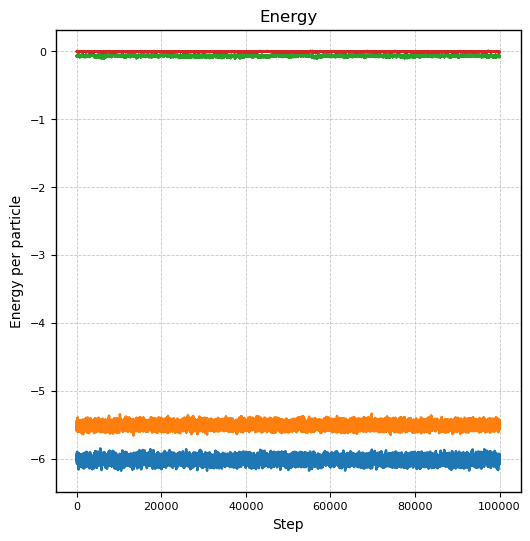

In [4]:
# Plot
plt.figure(figsize=(6, 6))

# 1
energy = np.loadtxt("./T0.85p0.86/energy.csv", delimiter=";")  # 0.42 acc rate
energy = energy[5000:] - 0.26*500
plt.plot(energy/N_particles)

tau = int(autocorrelation_time(energy))
print(tau)
print(np.mean(energy/N_particles))
print(np.std(energy/N_particles)*np.sqrt(2*tau/100000))


# 2
energy = np.loadtxt("./T0.85p0.776/energy.csv", delimiter=";")  # 0.50 acc rate
energy = energy[5000:]-120
plt.plot(energy/N_particles)

tau = int(autocorrelation_time(energy))
print(tau)
print(np.mean(energy/N_particles))
print(np.std(energy/N_particles)*np.sqrt(2*tau/100000))


# 3
energy = np.loadtxt("./T0.85p0.007/energy.csv", delimiter=";")  # 0.99 acc rate
energy = energy[5000:]-1.0854
plt.plot(energy/N_particles)

print(autocorrelation_time(energy))
print(np.mean(energy/N_particles))
print(np.std(energy/N_particles)*np.sqrt(1/100000))

# 4
energy = np.loadtxt("./T0.85p0.001/energy.csv", delimiter=";")  # 0.42 acc rate
energy = energy[5000:] - 0.155069
plt.plot(energy/N_particles)

print(autocorrelation_time(energy))
print(np.mean(energy/N_particles))
print(np.std(energy/N_particles)*np.sqrt(1/100000))

plt.title("Energy")
plt.grid(True)
plt.ylabel("Energy per particle")
plt.xlabel("Step")
plt.show()

data = np.loadtxt("output/specific_heat.csv", delimiter=";")
T = data[:,0]
CV = data[:,1]
# Plot
plt.figure(figsize=(6, 6))
plt.plot(T,CV, "-o")

plt.title("")
plt.grid(True)
plt.xlabel("T")
plt.ylabel("Cv")
plt.show()

In [16]:
def LJ_pot(x):
    return np.pow(x,-12) - np.pow(x,-6)

x = np.linspace(0.1,20,10000)
y = LJ_pot(x)


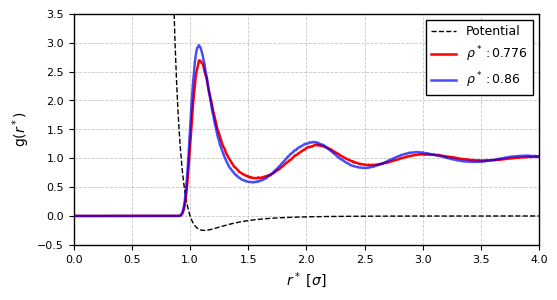

In [ ]:


# Plot
plt.figure(figsize=(6, 3))

plt.plot(x,y, color='black',
    linestyle='--',
    linewidth=1,label="Potential")

data = np.loadtxt("./T0.85p0.776/radial_distribution.csv", delimiter=";")
plt.plot(data[:,0], data[:,1], c="r", label=r"$\rho^*: 0.776$")

data = np.loadtxt("./T0.85p0.86/radial_distribution.csv", delimiter=";")
plt.plot(data[:,0], data[:,1], c="b", label=r"$\rho^*: 0.86$",alpha=0.7)

plt.title(r"")
plt.xlabel(r"$r^*$ [$\sigma$]")
plt.ylabel("g($r^*$)")
plt.legend()
plt.xlim([0,4])
plt.ylim([-0.5,3.5])
plt.grid(True)
plt.show()

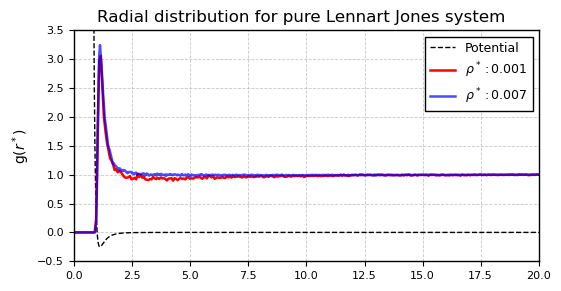

In [ ]:
# Plot
plt.figure(figsize=(6, 3))

plt.plot(x,y, color='black',
    linestyle='--',
    linewidth=1,label="Potential")

data = np.loadtxt("./T0.85p0.001/radial_distribution.csv", delimiter=";")
plt.plot(data[:,0], data[:,1], c="r", label=r"$\rho^*: 0.001$")

data = np.loadtxt("./T0.85p0.007/radial_distribution.csv", delimiter=";")
plt.plot(data[:,0], data[:,1], c="b", label=r"$\rho^*: 0.007$", alpha=0.7)

plt.title(r"Radial distribution for pure Lennart Jones system  ")
plt.ylabel("g($r^*$)")
plt.legend()
plt.xlim([0,20])
plt.ylim([-0.5,3.5])
plt.grid(True)
plt.show()